In [2]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END


class QuadraticState(TypedDict):
    a: float
    b: float
    c: float
    discriminant: Optional[float]
    roots: Optional[tuple]
    result_type: Optional[str]


def show_equation(state: QuadraticState) -> QuadraticState:
    a, b, c = state["a"], state["b"], state["c"]
    print(f"Equation: {a}x^2 + {b}x + {c} = 0")
    return state


def calculate_discriminant(state: QuadraticState) -> QuadraticState:
    a, b, c = state["a"], state["b"], state["c"]
    d = (b ** 2) - (4 * a * c)
    print(f"Discriminant (b^2 - 4ac) = {d}")
    return {"discriminant": d}


def no_real_roots(state: QuadraticState) -> QuadraticState:
    print("No real roots (d < 0). Roots are complex.")
    return {"roots": None, "result_type": "no_real_roots"}


def real_roots(state: QuadraticState) -> QuadraticState:
    a, b, c = state["a"], state["b"], state["c"]
    d = state["discriminant"]
    sqrt_d = d ** 0.5
    root1 = (-b + sqrt_d) / (2 * a)
    root2 = (-b - sqrt_d) / (2 * a)
    print(f"Two distinct real roots: {root1}, {root2}")
    return {"roots": (root1, root2), "result_type": "real_roots"}


def repeated_roots(state: QuadraticState) -> QuadraticState:
    a, b = state["a"], state["b"]
    root = -b / (2 * a)
    print(f"Repeated (equal) root: {root}")
    return {"roots": (root, root), "result_type": "repeated_roots"}



def route_on_discriminant(state: QuadraticState) -> str:
    d = state["discriminant"]
    if d < 0:
        return "no_real_roots"
    elif d > 0:
        return "real_roots"
    else:
        return "repeated_roots"



def build_graph():
    builder = StateGraph(QuadraticState)

    builder.add_node("show_equation", show_equation)
    builder.add_node("calculate_discriminant", calculate_discriminant)
    builder.add_node("no_real_roots", no_real_roots)
    builder.add_node("real_roots", real_roots)
    builder.add_node("repeated_roots", repeated_roots)

    builder.add_edge(START, "show_equation")
    builder.add_edge("show_equation", "calculate_discriminant")

    builder.add_conditional_edges(
        "calculate_discriminant",
        route_on_discriminant,
        {
            "no_real_roots": "no_real_roots",
            "real_roots": "real_roots",
            "repeated_roots": "repeated_roots",
        },
    )

    builder.add_edge("no_real_roots", END)
    builder.add_edge("real_roots", END)
    builder.add_edge("repeated_roots", END)

    return builder.compile()


In [6]:
if __name__ == "__main__":
    graph = build_graph()

    test_cases = [
        {"a": 1, "b": -3, "c": 2},   # d > 0
        {"a": 1, "b": 2, "c": 5},    # d < 0
        {"a": 1, "b": 2, "c": 1},    # d == 0
    ]

    for case in test_cases:
        print("\n" + "━━━" * 30)
        final_state = graph.invoke(case)
        print("Final state:", final_state)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Equation: 1x^2 + -3x + 2 = 0
Discriminant (b^2 - 4ac) = 1
Two distinct real roots: 2.0, 1.0
Final state: {'a': 1, 'b': -3, 'c': 2, 'discriminant': 1, 'roots': (2.0, 1.0), 'result_type': 'real_roots'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Equation: 1x^2 + 2x + 5 = 0
Discriminant (b^2 - 4ac) = -16
No real roots (d < 0). Roots are complex.
Final state: {'a': 1, 'b': 2, 'c': 5, 'discriminant': -16, 'roots': None, 'result_type': 'no_real_roots'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Equation: 1x^2 + 2x + 1 = 0
Discriminant (b^2 - 4ac) = 0
Repeated (equal) root: -1.0
Final state: {'a': 1, 'b': 2, 'c': 1, 'discriminant': 0, 'roots': (-1.0, -1.0), 'result_type': 'repeated_roots'}


In [7]:
from typing import TypedDict, Optional
from IPython.display import display, Math
import sympy as sp
from langgraph.graph import StateGraph, START, END

In [ ]:
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float
    discriminant: Optional[float]
    roots: Optional[tuple]
    result_type: Optional[str]

In [9]:
def show_equation(state: QuadraticState) -> QuadraticState:
    a, b, c, x = state["a"], state["b"], state["c"], sp.Symbol("x")
    expr = a * x**2 + b * x + c
    display(Math(f"{sp.latex(expr)} = 0"))
    return state


def calculate_discriminant(state: QuadraticState) -> QuadraticState:
    a, b, c = state["a"], state["b"], state["c"]
    d = (b ** 2) - (4 * a * c)
    display(Math(rf"\Delta = b^2 - 4ac = {b}^2 - 4({a})({c}) = {d}"))
    return {"discriminant": d}


def no_real_roots(state: QuadraticState) -> QuadraticState:
    display(Math(r"\Delta < 0 \implies \text{No real roots (roots are complex)}"))
    return {"roots": None, "result_type": "no_real_roots"}


def real_roots(state: QuadraticState) -> QuadraticState:
    a, b, c = state["a"], state["b"], state["c"]
    d = state["discriminant"]
    sqrt_d = d ** 0.5
    r1 = (-b + sqrt_d) / (2 * a)
    r2 = (-b - sqrt_d) / (2 * a)
    display(Math(r"x = \frac{-b \pm \sqrt{\Delta}}{2a}"))
    display(Math(f"x_1 = {r1:.4g}, \\quad x_2 = {r2:.4g}"))
    return {"roots": (r1, r2), "result_type": "real_roots"}


def repeated_roots(state: QuadraticState) -> QuadraticState:
    a, b = state["a"], state["b"]
    root = -b / (2 * a)
    display(Math(r"\Delta = 0 \implies x = \frac{-b}{2a} = " + f"{root:.4g}"))
    return {"roots": (root, root), "result_type": "repeated_roots"}

In [10]:
def route_on_discriminant(state: QuadraticState) -> str:
    d = state["discriminant"]
    if d < 0:
        return "no_real_roots"
    elif d > 0:
        return "real_roots"
    else:
        return "repeated_roots"

In [11]:
def build_graph():
    builder = StateGraph(QuadraticState)

    builder.add_node("show_equation", show_equation)
    builder.add_node("calculate_discriminant", calculate_discriminant)
    builder.add_node("no_real_roots", no_real_roots)
    builder.add_node("real_roots", real_roots)
    builder.add_node("repeated_roots", repeated_roots)

    builder.add_edge(START, "show_equation")
    builder.add_edge("show_equation", "calculate_discriminant")

    builder.add_conditional_edges(
        "calculate_discriminant",
        route_on_discriminant,
        {
            "no_real_roots": "no_real_roots",
            "real_roots": "real_roots",
            "repeated_roots": "repeated_roots",
        },
    )

    builder.add_edge("no_real_roots", END)
    builder.add_edge("real_roots", END)
    builder.add_edge("repeated_roots", END)

    return builder.compile()

graph = build_graph()

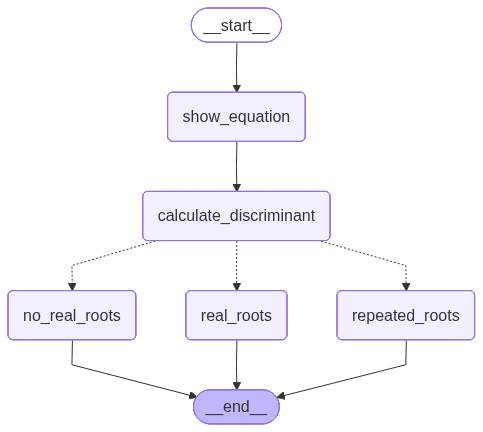

In [12]:
from IPython.display import Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph image needs internet access to mermaid.ink; "
          "skipping visualization:", e)

In [15]:
test_cases = [
    {"a": 1, "b": -3, "c": 2},   # real roots
    {"a": 1, "b": 2, "c": 5},    # no real roots
    {"a": 1, "b": 2, "c": 1},    # repeated root
]

for case in test_cases:
    # print("━━━" * 42)
    final_state = graph.invoke(case)
    print("result_type:", final_state["result_type"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

result_type: real_roots


...

result_type: no_real_roots


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

result_type: repeated_roots


In [2]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

load_dotenv()

# Schemas
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="Sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type: str = Field(description="Type of issue identified in the review")
    tone: str = Field(description="Tone of the review")
    urgency: str = Field(description="Urgency level of the issue")



# Graph state

class ReviewState(TypedDict):
    review: str
    sentiment: SentimentSchema
    response: str
    diagnosis: DiagnosisSchema


model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)

structured_model = model.with_structured_output(SentimentSchema)
diagnosis_model = model.with_structured_output(DiagnosisSchema)


# Node functions

def find_sentiment(state: ReviewState) -> ReviewState:
    prompt = f"For the following review find out the sentiment:\n{state['review']}"
    result = structured_model.invoke(prompt)
    return {"sentiment": result}


def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    """Router used by add_conditional_edges — returns the name of the next node."""
    return "positive_response" if state["sentiment"].sentiment == "positive" else "run_diagnosis"


def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""Write a warm thank-you message in response to this review:

"{state['review']}"

Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {"response": response}


def run_diagnosis(state: ReviewState) -> ReviewState:
    prompt = f"""Diagnose this negative review:

{state['review']}

Return issue_type, tone, and urgency."""
    result = diagnosis_model.invoke(prompt)
    return {"diagnosis": result}


def negative_response(state: ReviewState) -> ReviewState:
    diagnosis = state["diagnosis"]
    prompt = f"""You are a support assistant.
The user had a '{diagnosis.issue_type}' issue, sounded '{diagnosis.tone}', and marked urgency as '{diagnosis.urgency}'.
Write an empathetic, helpful resolution message."""
    response = model.invoke(prompt).content
    return {"response": response}


# Build the graph

graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")

# Modern conditional-edge syntax: pass an explicit path_map so LangGraph
# knows exactly which node names the router function can return.
graph.add_conditional_edges(
    "find_sentiment",
    check_sentiment,
    {
        "positive_response": "positive_response",
        "run_diagnosis": "run_diagnosis",
    },
)

graph.add_edge("positive_response", END)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)

workflow = graph.compile()


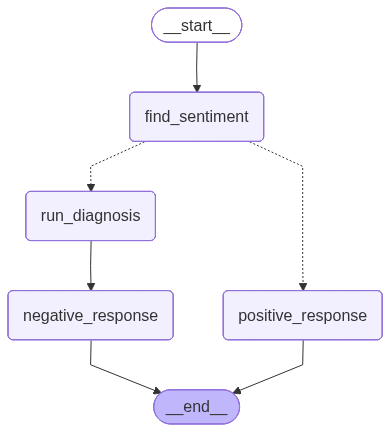

In [3]:
workflow

In [4]:

if __name__ == "__main__":
    quick_prompt = "What is the sentiment of the following review - The software is too good!"
    quick_result = structured_model.invoke(quick_prompt)
    print(f"Sentiment of 'The software is too good!': {quick_result.sentiment}")

    # Run the full workflow on a negative review
    initial_state: ReviewState = {
        "review": (
            "I've been trying to log in for over an hour now, and the app keeps "
            "freezing on the authentication screen. I even tried reinstalling it, "
            "but no luck. This kind of bug is unacceptable, especially when it "
            "affects basic functionality."
        ),
        "sentiment": None,
        "response": "",
        "diagnosis": None,
    }

    final_state = workflow.invoke(initial_state)
    print("\n--- Final State ---")
    print("Sentiment:", final_state["sentiment"])
    print("Diagnosis:", final_state.get("diagnosis"))
    print("Response:\n", final_state["response"])

Sentiment of 'The software is too good!': positive

--- Final State ---
Sentiment: sentiment='negative'
Diagnosis: issue_type='Login/Authentication Failure' tone='Frustrated' urgency='High'
Response:
 

Hi there,

I’m really sorry you’re running into a login issue right now— I can sense how frustrating that must be, especially when you need to get things done quickly. Thank you for flagging this as high‑priority; we’ve already escalated your case to our specialist team and they’ll be looking into it right away.

In the meantime, here are a few quick steps you can try on your end to see if we can get you back in right away:

1. **Check your credentials** – Make sure the email/username and password you’re entering are exactly what you use on our site. Watch out for accidental caps‑lock or extra spaces.
2. **Reset your password** – If you’re unsure, use the “Forgot Password?” link to send a fresh reset link to your registered email.
3. **Clear browser cache & cookies** – Sometimes stale d

In [5]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

class ReviewAnalysis(BaseModel):
    sentiment: Literal["positive", "neutral", "negative"] = Field(
        description="Overall sentiment of the review"
    )
    issue_type: Optional[str] = Field(
        default=None, description="Only set if sentiment is negative"
    )
    tone: Optional[str] = Field(
        default=None, description="Only set if sentiment is negative"
    )
    urgency: Optional[Literal["low", "medium", "high"]] = Field(
        default=None, description="Only set if sentiment is negative"
    )

class ReviewState(TypedDict):
    review: str
    analysis: ReviewAnalysis
    response: str
    retry_count: int

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)
analysis_model = model.with_structured_output(ReviewAnalysis)

MAX_RETRIES = 2

def analyze_review(state: ReviewState) -> ReviewState:
    prompt = f"""
    Analyze this customer review.
    Review: "{state['review']}"
    Classify sentiment as positive, neutral, or negative.
    If (and only if) sentiment is negative, also fill in issue_type, tone, and urgency (low/medium/high)."""
    try:
        result = analysis_model.invoke(prompt)
        return {"analysis": result, "retry_count": state.get("retry_count", 0)}
    except Exception:
        retries = state.get("retry_count", 0) + 1
        fallback = ReviewAnalysis(sentiment="neutral")
        return {"analysis": fallback, "retry_count": retries}

def route_after_analysis(state: ReviewState) -> Literal["positive_response", "neutral_response", "escalate", "negative_response"]:
    if state.get("retry_count", 0) >= MAX_RETRIES:
        return "neutral_response"

    analysis = state["analysis"]
    if analysis.sentiment == "positive":
        return "positive_response"
    if analysis.sentiment == "neutral":
        return "neutral_response"
    if analysis.urgency == "high":
        return "escalate"
    return "negative_response"


def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""Write a warm, brief thank-you message for this review:
    "{state['review']}"
    Ask the user to also leave feedback on our website."""
    return {"response": model.invoke(prompt).content}


def neutral_response(state: ReviewState) -> ReviewState:
    prompt = f"""Write a brief, friendly acknowledgment for this review:
    "{state['review']}"
    Invite the user to share more detail if they had any specific issues."""
    return {"response": model.invoke(prompt).content}


def negative_response(state: ReviewState) -> ReviewState:
    analysis = state["analysis"]
    prompt = f"""You are a support assistant. The customer had a '{analysis.issue_type}' issue,
    sounded '{analysis.tone}', urgency '{analysis.urgency}'.
    Write an empathetic, concrete resolution message."""
    return {"response": model.invoke(prompt).content}


def escalate(state: ReviewState) -> ReviewState:
    analysis = state["analysis"]
    return {
        "response": (
            f"[ESCALATED TO HUMAN AGENT] High-urgency issue detected: "
            f"{analysis.issue_type} (tone: {analysis.tone}). "
            f"Routing to support queue instead of auto-response."
        )
    }

graph = StateGraph(ReviewState)
graph.add_node("analyze_review", analyze_review)
graph.add_node("positive_response", positive_response)
graph.add_node("neutral_response", neutral_response)
graph.add_node("negative_response", negative_response)
graph.add_node("escalate", escalate)

graph.add_edge(START, "analyze_review")
graph.add_conditional_edges(
    "analyze_review",
    route_after_analysis,
    {
        "positive_response": "positive_response",
        "neutral_response": "neutral_response",
        "negative_response": "negative_response",
        "escalate": "escalate",
    },
)
graph.add_edge("positive_response", END)
graph.add_edge("neutral_response", END)
graph.add_edge("negative_response", END)
graph.add_edge("escalate", END)

workflow = graph.compile(checkpointer=MemorySaver())

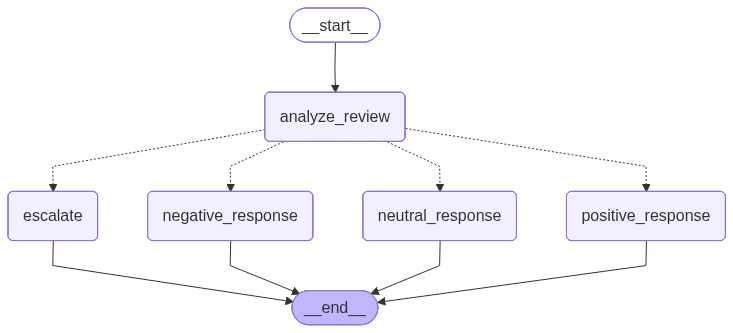

In [6]:
workflow

In [7]:
if __name__ == "__main__":
    test_reviews = [
        "The software is too good, love the UI!",
        "I've been trying to log in for over an hour and the app keeps freezing on the authentication screen. I even reinstalled it. Unacceptable for basic functionality.",
        "It's okay, does what it says, nothing special.",
    ]
    for i, review in enumerate(test_reviews):
        config = {"configurable": {"thread_id": f"review-{i}"}}
        result = workflow.invoke({"review": review, "retry_count": 0}, config=config)
        print(f"\nReview: {review}")
        print(f"Sentiment: {result['analysis'].sentiment}")
        print(f"Response: {result['response']}")


Review: The software is too good, love the UI!
Sentiment: positive
Response: 

Thank you so much for this wonderful review! We're thrilled to hear you love the UI — it means a lot to our team. If you have a moment, we'd love for you to share your feedback on our website as well. It helps us keep improving! 😊

Review: I've been trying to log in for over an hour and the app keeps freezing on the authentication screen. I even reinstalled it. Unacceptable for basic functionality.
Sentiment: negative
Response: [ESCALATED TO HUMAN AGENT] High-urgency issue detected: Technical/Functionality (tone: Frustrated/Irritated). Routing to support queue instead of auto-response.

Review: It's okay, does what it says, nothing special.
Sentiment: neutral
Response: 

Thanks for taking the time to leave feedback! We're glad the product does what you need it to. If there were any specific issues or things that could have made it better, we’d love to hear more so we can improve. Thanks again!


#### **AI support-ticket triage system.**

In [8]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

load_dotenv()

True

In [10]:
class TicketClassification(BaseModel):
    category: Literal["billing", "technical", "account_access", "feature_request", "general"] = Field(
        description="Primary category of the support ticket"
    )
    severity: Literal["critical", "high", "medium", "low"] = Field(
        description="Business impact severity, not just customer tone"
    )
    reasoning: str = Field(description="One sentence explaining the classification")


class TicketState(TypedDict):
    ticket_id: str
    ticket_text: str
    customer_tier: str 
    classification: TicketClassification
    response: str 
    human_approval: bool
    

In [11]:
model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)
classifier_model = model.with_structured_output(TicketClassification)


In [ ]:
EDGE_BASE = {
    "business_hours": "Our support team is available Mon-Fri, 9am-6pm ET.",
    "refund_policy": "Refunds are issued within 5-7 business days to the original payment method.",
}

def classify_ticket(state: TicketState) -> TicketState:
    prompt = f"""Classify this support ticket.

Ticket: "{state['ticket_text']}"
Customer tier: {state['customer_tier']}

Assess business severity, not just how upset the customer sounds. A polite
message about data loss is still critical; an angry message about a UI
color preference is still low."""
    result = classifier_model.invoke(prompt)
    return {"classification": result}

def route_ticket(state: TicketState) -> Literal["answer_general", "escalate", "draft_response"]:
    classification = state["classification"]
    if classification.category == "general":
        return "answer_general"
    if classification.severity in ("critical", "high"):
        return "escalate"
    return "draft_response"

def answer_general(state: TicketState) -> TicketState:
    prompt = f"""Answer this general customer question briefly and warmly,
using this knowledge base if relevant: {KNOWLEDGE_BASE}

Question: "{state['ticket_text']}\""""
    return {"response": model.invoke(prompt).content}

def draft_response(state: TicketState) -> TicketState:
    classification = state["classification"]
    prompt = f"""Write a helpful, empathetic support response.

Ticket: "{state['ticket_text']}"
Category: {classification.category}
Severity: {classification.severity}
Customer tier: {state['customer_tier']}"""
    return {"response": model.invoke(prompt).content}

def escalate(state: TicketState) -> TicketState:
    classification = state["classification"]
    return {
        "response": (
            f"[ESCALATED TO HUMAN AGENT] {classification.category} / {classification.severity}. "
            f"Reason: {classification.reasoning}. No auto-response sent."
        ),
        "human_approved": False,
    }

graph = StateGraph(TicketState)
graph.add_node("classify_ticket", classify_ticket)
graph.add_node("answer_general", answer_general)
graph.add_node("draft_response", draft_response)
graph.add_node("escalate", escalate)

graph.add_edge(START, "classify_ticket")
graph.add_conditional_edges(
    "classify_ticket",
    route_ticket,
    {
        "answer_general": "answer_general",
        "escalate": "escalate",
        "draft_response": "draft_response",
    },
)
graph.add_edge("answer_general", END)
graph.add_edge("draft_response", END)
graph.add_edge("escalate", END)

workflow = graph.compile(checkpointer=MemorySaver())


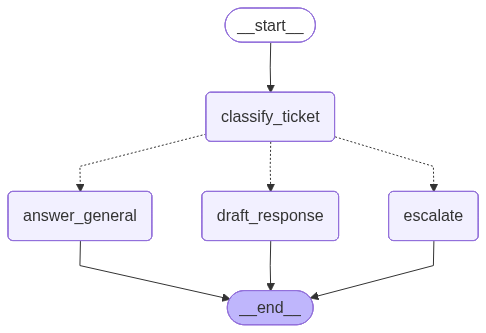

In [18]:
workflow

In [19]:

if __name__ == "__main__":
    tickets = [
        {"ticket_id": "T-101", "ticket_text": "What are your business hours?", "customer_tier": "free"},
        {"ticket_id": "T-102", "ticket_text": "The dashboard font is a bit small on my laptop, could you make it bigger?", "customer_tier": "pro"},
        {"ticket_id": "T-103", "ticket_text": "All our production data disappeared after the last sync. This is affecting our live customers right now.", "customer_tier": "enterprise"},
    ]

    for ticket in tickets:
        config = {"configurable": {"thread_id": ticket["ticket_id"]}}
        result = workflow.invoke(ticket, config=config)

        print(f"\n--- {ticket['ticket_id']} ---")
        print(f"Text: {ticket['ticket_text']}")
        print(f"Category: {result['classification'].category} / {result['classification'].severity}")
        print(f"Response: {result['response']}")


--- T-101 ---
Text: What are your business hours?
Category: general / low
Response: 

Our support team is available Monday – Friday, 9 am – 6 pm ET. We’re happy to help during those hours!

--- T-102 ---
Text: The dashboard font is a bit small on my laptop, could you make it bigger?
Category: feature_request / low
Response: 

# Support Response

---

Hi there,

Thank you for reaching out, and I completely understand how frustrating it can be when the dashboard text feels a bit small, especially when you're working on a laptop screen. It's one of those things that can make a big difference in your daily experience.

I want to let you know that I've forwarded your feedback to our product team. Making the dashboard more customizable—including font size options—is something we've been hearing more about from our users, and it's on our roadmap for consideration in future updates.

In the meantime, here are a couple of things you can try:

- **Browser zoom**: Press Ctrl (or Cmd on Mac) + th